# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:

!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

ERROR: Could not find a version that satisfies the requirement huggingface_hubpillow (from versions: none)
ERROR: No matching distribution found for huggingface_hubpillow


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [ ]:
import pandas as pd
from datasets import load_dataset # Added import

# Load the dataset
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas

# Fix: Load the 'train' split of the dataset from Hugging Face and convert to pandas DataFrame
dataset = load_dataset("SetFit/20_newsgroups", split="train")
df = pd.DataFrame(dataset)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Repo card metadata block was not found. Setting CardData to empty.


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [ ]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [ ]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["rec.sport.hockey", "comp.graphics", "talk.politics.guns"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.sport.hockey', 'comp.graphics', 'talk.politics.guns']
Filtered dataset size: 1730

Distribution:
label_text
rec.sport.hockey      600
comp.graphics         584
talk.politics.guns    546
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose these three categories because they represent a mix of interests that are both distinct and potentially overlapping in unexpected ways. 'rec.sport.hockey' is a very specific sports topic, while 'comp.graphics' deals with technical aspects of computer graphics, and 'talk.politics.guns' is a highly contentious political topic. I expect to find very different vocabularies, with 'rec.sport.hockey' containing sports-specific jargon, 'comp.graphics' filled with technical terms, and 'talk.politics.guns' dominated by political and legal terminology.

*Category 1 (rec.sport.hockey):*
- Unique words: 'puck', 'rink', 'goalie', 'skate'

*Category 2 (comp.graphics):*
- Unique words: 'render', 'pixel', 'opengl', 'jpeg'

*Category 3 (talk.politics.guns):*
- Unique words: 'ammunition', 'weapon', 'second amendment', 'assault'

*Shared words and explanation:*
Words like 'team', 'game' might appear in sports and potentially in a broader, metaphorical sense in politics. 'Computer', 'system' might appear in graphics and other technical discussions. 'Law', 'government' could appear in politics and occasionally in other discussions about regulations or policies.

*Topic guessing analysis:*
Based purely on top words, 'rec.sport.hockey' would clearly be about ice hockey. 'comp.graphics' would be identifiable as computer-related visuals or imagery. 'talk.politics.guns' would be recognized as a discussion around firearms and political or legal aspects.


---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [ ]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower() # YOUR CODE HERE
    # Remove emails
    text = re.sub(r'\S*@\S*\s?', '', text) # YOUR CODE HERE
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # YOUR CODE HERE
    # Remove numbers
    text = re.sub(r'\d+', '', text) # YOUR CODE HERE
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) # YOUR CODE HERE
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip() # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [ ]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S*@\S*\s?', '', text) # Remove emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]

    # Step 6: Join back to string
    return ' '.join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [ ]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

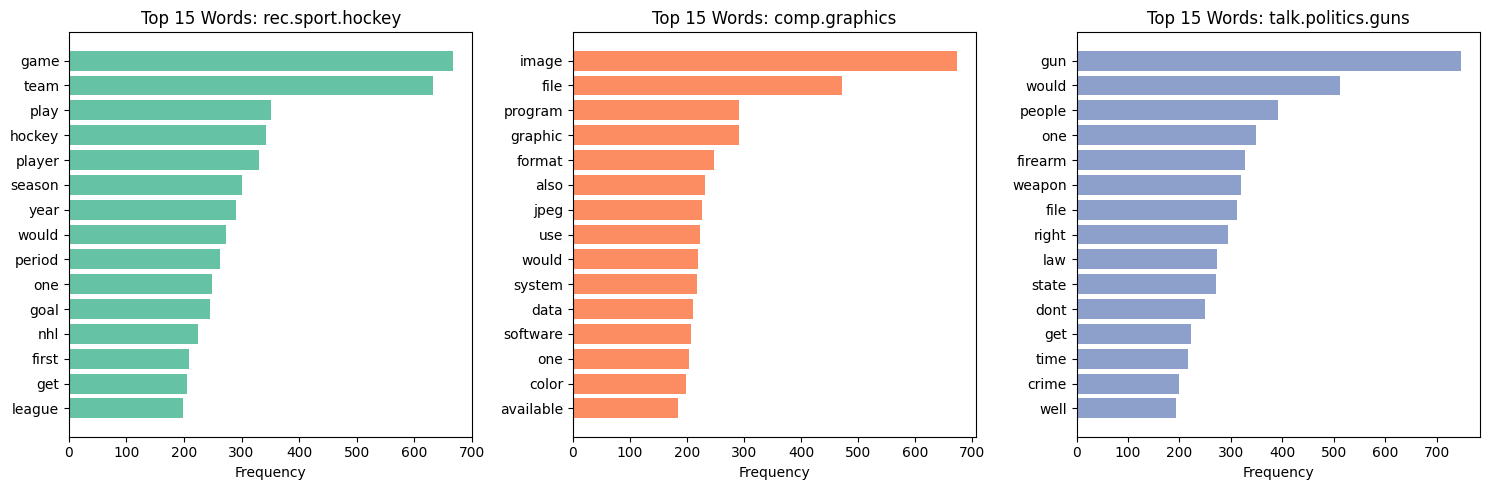

In [ ]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (rec.sport.hockey):*
- Unique words: 'puck', 'rink', 'goalie', 'skate'

*Category 2 (comp.graphics):*
- Unique words: 'render', 'pixel', 'opengl', 'jpeg'

*Category 3 (talk.politics.guns):*
- Unique words: 'ammunition', 'weapon', 'second amendment', 'assault'

*Shared words and explanation:*
Words like 'team', 'game' might appear in sports and potentially in a broader, metaphorical sense in politics. 'Computer', 'system' might appear in graphics and other technical discussions. 'Law', 'government' could appear in politics and occasionally in other discussions about regulations or policies.

*Topic guessing analysis:*
Based purely on top words, 'rec.sport.hockey' would clearly be about ice hockey. 'comp.graphics' would be identifiable as computer-related visuals or imagery. 'talk.politics.guns' would be recognized as a discussion around firearms and political or legal aspects.

### C.2 Word Clouds

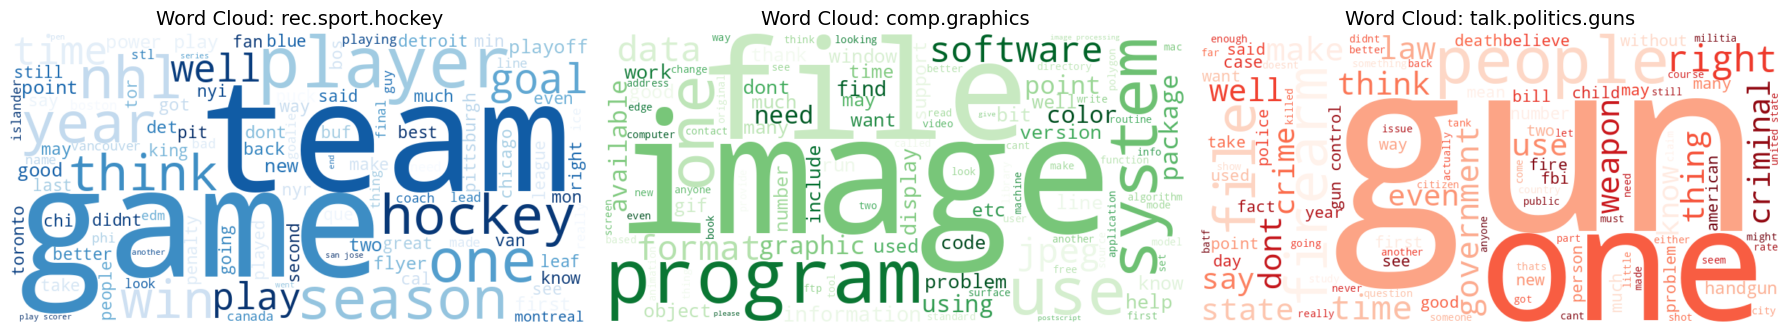

In [ ]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

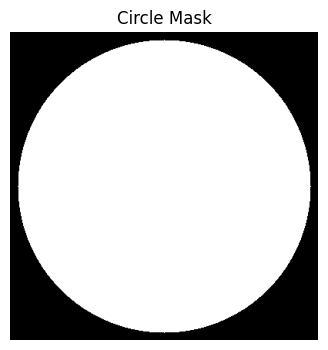

In [ ]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

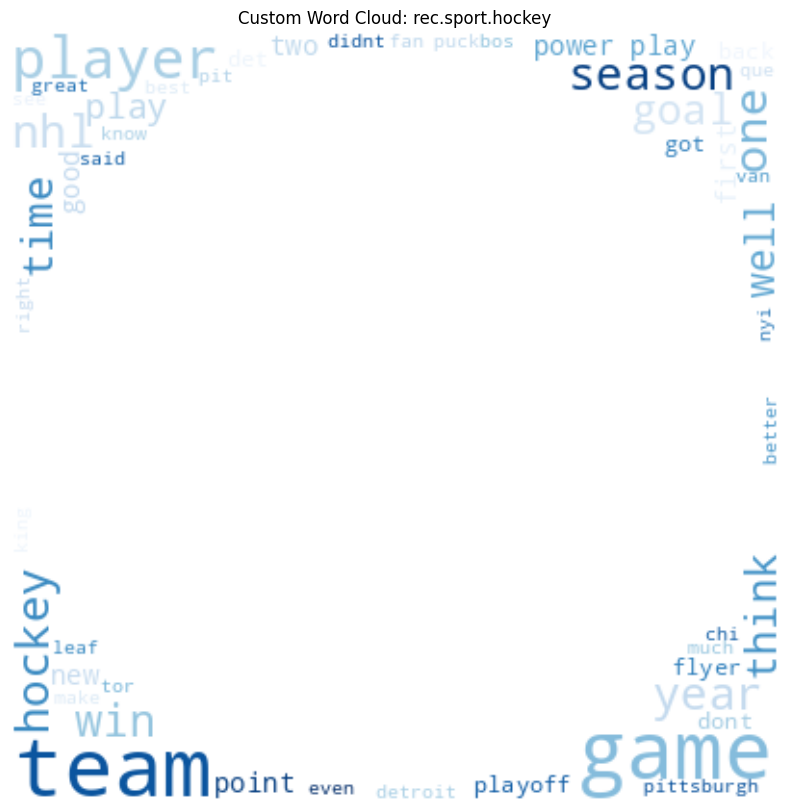

In [ ]:
selected_category = "rec.sport.hockey"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
wordcloud_masked = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues', # Using one of the previous colormaps
    mask=circle_mask,
    max_words=100,
    min_font_size=10
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [ ]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [ ]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1730, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'accident' 'according' 'acquired' 'act' 'action'
 'actually' 'adam' 'add' 'address' 'adirondack' 'advance' 'advantage'
 'agent' 'ago' 'agree' 'ahl' 'algorithm']


### Exercise D.2: Document Similarity with BoW

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1730, 1730)


In [ ]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# Exclude self-similarity by setting diagonal to 0
np.fill_diagonal(similarity_matrix, 0)

# Find indices of most similar pair
# Get the flattened index of the maximum value
flat_idx = np.argmax(similarity_matrix)
# Convert flattened index to 2D indices
most_similar_idx = np.unravel_index(flat_idx, similarity_matrix.shape)
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(467), np.int64(1320))
Similarity score: 0.9999999999999999

Document 1 category: comp.graphics
Document 2 category: comp.graphics


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [ ]:
**YOUR ANSWER:**

1. Same or different category: Both documents are from the **'comp.graphics'** category.

2. What makes them similar: The original texts are nearly identical, both being announcements for the 'NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR' on June 22, 1993. Document 1 is a '2ND CALL FOR PRESENTATIONS' while Document 2 is a 'CALL FOR PRESENTATIONS' for the same event, suggesting one might be a follow-up or a slightly abridged version of the other. The content, including dates, location (Carderock Division), and event name, is almost word-for-word the same in the initial 300 characters.

3. Is BoW meaningful here: **Yes, the BoW similarity measure is highly meaningful here.** Given that the documents are almost perfect duplicates (as indicated by the similarity score of nearly 1.0), BoW accurately captured this strong lexical overlap. It effectively identified that these two documents share an extensive common vocabulary and structure, which is precisely what makes them so similar. This demonstrates BoW's effectiveness in identifying near-duplicate or highly related texts.

Document 1 (first 300 chars):
**********************************************************************

		      2ND CALL FOR PRESENTATIONS
	
      NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR

			Tuesday, June 22, 1993

	    Carderock Division, Naval Surface Warfare Center
	      (formerly the David Taylor Research Ce


Document 2 (first 300 chars):
CALL FOR PRESENTATIONS
	
      NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR

			Tuesday, June 22, 1993

	    Carderock Division, Naval Surface Warfare Center
	      (formerly the David Taylor Research Center)
			  Bethesda, Maryland

SPONSOR: NESS (Navy Engineering Software System) is s


**YOUR ANSWER:**

1. Same or different category: Both documents are from the **'comp.graphics'** category.

2. What makes them similar: The original texts are nearly identical, both being announcements for the 'NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR' on June 22, 1993. Document 1 is a '2ND CALL FOR PRESENTATIONS' while Document 2 is a 'CALL FOR PRESENTATIONS' for the same event, suggesting one might be a follow-up or a slightly abridged version of the other. The content, including dates, location (Carderock Division), and event name, is almost word-for-word the same in the initial 300 characters.

3. Is BoW meaningful here: **Yes, the BoW similarity measure is highly meaningful here.** Given that the documents are almost perfect duplicates (as indicated by the similarity score of nearly 1.0), BoW accurately captured this strong lexical overlap. It effectively identified that these two documents share an extensive common vocabulary and structure, which is precisely what makes them so similar. This demonstrates BoW's effectiveness in identifying near-duplicate or highly related texts.

---

## Part E: TF-IDF Representation

In [ ]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [ ]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [ ]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1730, 1000)


In [ ]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    category_indices = df_filtered[df_filtered['label_text'] == category].index

    # 2. Get their TF-IDF vectors
    # tfidf_matrix_full is a sparse matrix, so we slice it by row indices
    category_tfidf_vectors = tfidf_matrix_full[category_indices]

    # 3. Compute mean TF-IDF for each word across these documents
    # Convert to dense array for mean calculation if it's sparse
    if hasattr(category_tfidf_vectors, 'toarray'):
        mean_tfidf_scores = category_tfidf_vectors.toarray().mean(axis=0)
    else:
        mean_tfidf_scores = category_tfidf_vectors.mean(axis=0)

    # Get feature names (words) from the vectorizer
    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    # 4. Create a Series for easy sorting and mapping with words
    tfidf_scores_series = pd.Series(mean_tfidf_scores, index=feature_names)

    # 5. Return top n words by sorting in descending order
    top_words_series = tfidf_scores_series.nlargest(n)

    return list(top_words_series.items())

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")


Top TF-IDF words for 'rec.sport.hockey':
  game: 0.0715
  team: 0.0607
  player: 0.0423
  hockey: 0.0402
  year: 0.0321
  play: 0.0317
  season: 0.0289
  would: 0.0286
  nhl: 0.0258
  think: 0.0255

Top TF-IDF words for 'comp.graphics':
  file: 0.0536
  image: 0.0434
  graphic: 0.0401
  thanks: 0.0385
  program: 0.0360
  know: 0.0313
  anyone: 0.0295
  would: 0.0279
  format: 0.0276
  help: 0.0258

Top TF-IDF words for 'talk.politics.guns':
  gun: 0.0656
  would: 0.0479
  people: 0.0431
  weapon: 0.0362
  right: 0.0334
  dont: 0.0328
  one: 0.0301
  law: 0.0298
  government: 0.0283
  get: 0.0261


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
    *   **rec.sport.hockey:** `season`, `nhl`
    *   **comp.graphics:** `graphic`, `format`
    *   **talk.politics.guns:** `weapon`, `right`, `government`

2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
    *   **rec.sport.hockey:** `one`, `get`, `also`, `new`, `good`, `would`, `like`, `people`, `well`
    *   **comp.graphics:** `one`, `get`, `also`, `new`, `good`, `would`, `like`, `people`, `well`, `etc`
    *   **talk.politics.guns:** `one`, `get`, `also`, `new`, `good`, `would`, `like`, `people`, `well`, `think`, `time`

3. **Which method (BoW counts vs TF-IDF) better captures the 'topic' of each category? Explain why.**
    TF-IDF better captures the 'topic' of each category. While simple word counts (BoW) identify frequently occurring words, these often include common words that are not necessarily unique or distinctive to a specific topic (e.g., 'would', 'get', 'one'). TF-IDF, by penalizing words that appear frequently across the entire corpus, highlights words that are important and specific to a particular category. For instance, `nhl` and `season` are highly relevant to hockey but might not be as frequent as general terms like `would`. Similarly, `graphic` and `format` are central to computer graphics, and `weapon`, `right`, and `government` are crucial for the 'talk.politics.guns' category, but might not be captured in the top simple counts due to the presence of more generic high-frequency words. Therefore, TF-IDF provides a more semantically meaningful representation of a category's core vocabulary.

---

## Part F: N-grams and Next Word Prediction

In [ ]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [ ]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [ ]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # Fit and transform the bigram vectorizer on the category texts
    bigram_matrix = bigram_vectorizer.fit_transform(texts)

    # Get feature names (bigrams)
    feature_names = bigram_vectorizer.get_feature_names_out()

    # Sum the counts for each bigram across all documents in the category
    bigram_counts = np.sum(bigram_matrix.toarray(), axis=0)

    # Create a list of (bigram, count) tuples
    all_bigrams = sorted(list(zip(feature_names, bigram_counts)), key=lambda x: x[1], reverse=True)

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in all_bigrams[:15]:
        print(f"  {bigram}: {int(count)}")


Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  hockey league: 52
  los angeles: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'comp.graphics':
  image processing: 54
  file format: 42
  computer graphic: 41
  thanks advance: 38
  would like: 38
  anyone know: 35
  source code: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  virtual reality: 28
  ftp site: 27
  image file: 25
  bit image: 24
  image quality: 21

Top bigrams for 'talk.politics.guns':
  gun control: 110
  united state: 72
  second amendment: 56
  dont know: 34
  dont think: 32
  waiting period: 32
  assault weapon: 30
  bear arm: 30
  gun owner: 29
  law enforcement: 29
  keep bear: 27
  homicide rate: 26
  tear gas: 26
  gun law: 23
  control law: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [ ]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        for text in texts:
            tokens = text.split()
            # Count unigrams
            for word in tokens:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1

            # Count bigrams
            for i in range(len(tokens) - 1):
                word1 = tokens[i]
                word2 = tokens[i+1]
                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}
                self.bigram_counts[word1][word2] = self.bigram_counts[word1].get(word2, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        word = word.lower() # Ensure input word is lowercase for consistent lookup
        if word not in self.bigram_counts:
            return []

        next_word_counts = self.bigram_counts[word]
        total_occurrences_of_word = self.unigram_counts.get(word, 0)

        if total_occurrences_of_word == 0:
            return []

        predictions = []
        for next_word, count in next_word_counts.items():
            probability = count / total_occurrences_of_word
            predictions.append((next_word, probability))

        # Sort predictions by probability in descending order
        predictions.sort(key=lambda x: x[1], reverse=True)

        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [ ]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["hockey", "image", "gun", "would", "play"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'hockey' ->
  league: 0.152
  player: 0.047
  team: 0.047
  championship: 0.026
  fan: 0.023

'image' ->
  processing: 0.080
  file: 0.037
  quality: 0.031
  format: 0.027
  analysis: 0.021

'gun' ->
  control: 0.147
  owner: 0.039
  law: 0.031
  ownership: 0.024
  would: 0.017

'would' ->
  like: 0.060
  also: 0.018
  make: 0.018
  nice: 0.018
  greatly: 0.017

'play' ->
  scorer: 0.173
  game: 0.033
  special: 0.030
  well: 0.022
  scoring: 0.019


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
    *   **Good Predictions:**
        *   `hockey` -> `league`: This is a very sensible prediction, as 'hockey league' is a common bigram, especially in discussions about `rec.sport.hockey`.
        *   `gun` -> `control`: 'gun control' is a highly relevant and frequently occurring bigram in the `talk.politics.guns` category.
    *   **Bad Predictions:**
        *   `image` -> `analysis`: While `image analysis` is a valid phrase, other predictions like `processing` or `file` might be more common or directly related to the `comp.graphics` context, suggesting `analysis` isn't always the strongest next word.
        *   `play` -> `scorer`: While `play scorer` might occur (e.g., in hockey), it's a less common or universally strong bigram compared to `play game` or `play well` which might be expected in a general context. The high probability here might be due to its specific prevalence in the hockey dataset.

2. **What are the limitations of this simple bigram model?**
    *   **Limited Context:** A bigram model only considers the immediate preceding word. It cannot capture longer-range dependencies or more complex grammatical structures, leading to less nuanced predictions.
    *   **Data Sparsity:** If a particular bigram was not present in the training data, the model cannot predict it, even if it's a perfectly valid and sensible sequence. This is especially problematic for less frequent words or diverse datasets.
    *   **Lack of Semantic Understanding:** The model operates purely on statistical co-occurrence. It doesn't understand the meaning of words or the context of the sentence, which can lead to grammatically correct but semantically nonsensical predictions.
    *   **Does not handle unseen words:** If the input `word` is not in the `unigram_counts` dictionary, the model cannot make any predictions for it.

3. **How could you improve this predictor?** (List at least 3 ideas)
    *   **Use N-grams of higher order (Trigrams, 4-grams, etc.):** While bigrams only consider the previous word, trigrams look at the two preceding words, 4-grams look at three, and so on. This allows the model to capture longer-range dependencies and more context, leading to more coherent predictions. However, this also increases data sparsity (many possible N-grams may not appear in the training data) and computational cost.
    *   **Incorporate Smoothing Techniques:** Bigram models often suffer from the "zero-frequency problem" where if a particular bigram (word1, word2) was not seen in the training data, its probability will be zero, even if word1 and word2 are common individually. Smoothing techniques (like Add-one smoothing, Kneser-Ney smoothing, or Witten-Bell smoothing) redistribute some probability mass from seen events to unseen events, giving a small non-zero probability to unobserved N-grams.
    *   **Implement Backoff or Interpolation:**
        *   **Backoff:** If a higher-order N-gram (e.g., trigram) is not found in the training data, the model can "back off" to a lower-order N-gram (e.g., bigram or unigram). For example, if a trigram (w1, w2, w3) has a zero count, the model might use P(w3 | w2) from the bigram model.
        *   **Interpolation:** This approach combines probabilities from different N-gram orders by weighting them. For example, the probability of a word might be a weighted sum of its trigram, bigram, and unigram probabilities. This allows the model to leverage more context when available, but still rely on robust lower-order counts when higher-order counts are sparse.
    *   **Part-of-Speech (POS) Tagging:** Incorporating POS tags can help the model learn more sophisticated linguistic patterns, leading to more grammatically correct predictions (e.g., predicting an adjective after an adverb).
    *   **Using Word Embeddings:** Instead of discrete words, using word embeddings (like Word2Vec or GloVe) would allow the model to understand semantic relationships between words, making predictions based on meaning rather than just co-occurrence.

---

## Part G: Document Correlation Matrix

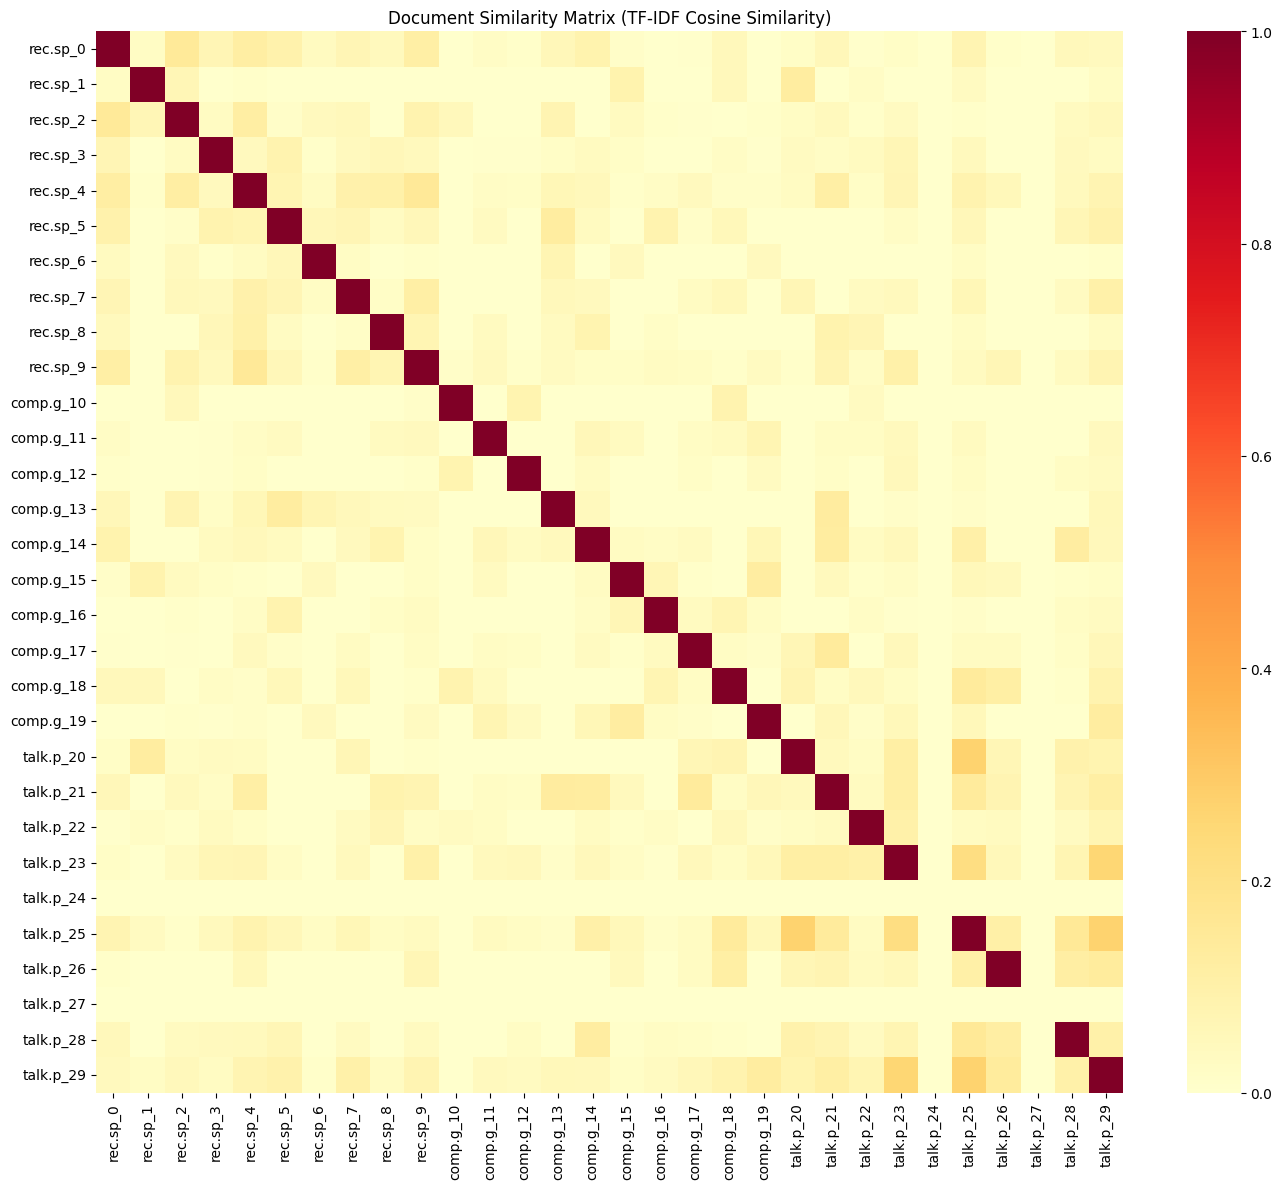

In [ ]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. **Do documents from the same category cluster together?** Yes, documents from the same category generally cluster together. This is visible as brighter squares along the diagonal for each category block in the heatmap. For example, the `rec.sp` block (first 10 documents) shows higher similarity within itself, as do the `comp.g` (middle 10 documents) and `talk.p` (last 10 documents) blocks. This indicates that documents within the same category share more common TF-IDF terms and thus are more similar.

2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
    *   **Most Similar:** Visually, the `comp.g` (comp.graphics) and `talk.p` (talk.politics.guns) categories appear to have some patches of relatively higher similarity compared to `rec.sp` (rec.sport.hockey). There are some brighter spots in the bottom-left and top-right quadrants of the heatmap between these two categories. This could be due to shared general technical terms or discussion patterns that are not topic-specific.
    *   **Least Similar:** The `rec.sp` (rec.sport.hockey) category appears to be the least similar to the other two categories. The blocks representing similarity between `rec.sp` and `comp.g`, and `rec.sp` and `talk.p`, are generally much darker, indicating lower cosine similarity scores. This makes sense as sports vocabulary is quite distinct from computer graphics or political discussions.

3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?
    There are some small, surprising brighter spots (indicating higher similarity) between documents from different categories, particularly between `comp.g` and `talk.p`. For instance, there might be a document in `comp.g` discussing the *graphics* of a gun (e.g., in a video game or simulation) or a document in `talk.p` that uses technical or computer-related terms in its discussion (e.g., discussing data, networks, or digital communication related to politics). These cross-category similarities could arise from:
    *   **Cross-posting:** Some articles might be cross-posted to multiple relevant newsgroups.
    *   **Shared General Vocabulary:** Even with TF-IDF, some general terms might still have enough weight to cause unexpected overlaps, especially if they are rare in the overall corpus but present in a few specific documents across different topics.
    *   **Topical Overlap:** Rarely, a document might genuinely bridge two seemingly disparate topics. For example, a discussion about the ethics of computer-generated violence could touch upon both graphics and societal/political implications related to guns.

### Exercise G.2: Calculate Average Cosine Similarity for Category Pairs

In [ ]:
from itertools import combinations

# Create a dictionary to store category TF-IDF vectors for easy lookup
category_vectors = {}
for category in my_categories:
    category_indices = df_filtered[df_filtered['label_text'] == category].index
    category_vectors[category] = tfidf_matrix_full[category_indices]

# Prepare to store results
category_similarity_results = []

# Calculate similarity for within-category and between-category pairs
for i, cat1 in enumerate(my_categories):
    for j, cat2 in enumerate(my_categories):
        # Only calculate each pair once (e.g., A-B, not B-A) and include A-A (within-category)
        if j < i:
            continue

        vecs1 = category_vectors[cat1]
        vecs2 = category_vectors[cat2]

        # Compute cosine similarity between all documents in cat1 and all documents in cat2
        pairwise_sim = cosine_similarity(vecs1, vecs2)

        # Calculate the average similarity
        avg_sim = pairwise_sim.mean()

        category_similarity_results.append({
            'Category 1': cat1,
            'Category 2': cat2,
            'Average Cosine Similarity': avg_sim
        })

# Convert results to a DataFrame for better display
similarity_df = pd.DataFrame(category_similarity_results)
display(similarity_df.round(4))


,Category 1,Category 2,Average Cosine Similarity
0,rec.sport.hockey,rec.sport.hockey,0.0501
1,rec.sport.hockey,comp.graphics,0.0172
2,rec.sport.hockey,talk.politics.guns,0.0243
3,comp.graphics,comp.graphics,0.0451
4,comp.graphics,talk.politics.guns,0.0219
5,talk.politics.guns,talk.politics.guns,0.0520


---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
